# 📊 Exploratory Data Analysis (تحليل البيانات الاستكشافي) (EDA)
**Day 2 — Data is Everything**

---

## Why Data Quality Drives Model Quality

There's a saying in Machine Learning (التعلم الآلي): **"garbage in, garbage out."** No matter how sophisticated your algorithm is, if your data is messy, biased, or incomplete, your model will learn the wrong things.

Before touching a single algorithm, every professional data scientist spends time *understanding their data*. This process is called **Exploratory Data Analysis (تحليل البيانات الاستكشافي) (EDA)**.

In this notebook you will learn to:
- Load and inspect a dataset
- Understand distributions (what values are typical, what's unusual?)
- Find missing values
- Discover correlations between features
- Spot potential data quality issues

We'll use the **Titanic** dataset — data from the 1912 disaster. The task: predict who survived.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load the Titanic dataset (famous in ML — great for learning with)
try:
    df = sns.load_dataset("titanic")
except:
    # Fallback URL
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    if "pclass" not in df.columns and "Pclass" in df.columns:
        df = df.rename(columns={"Pclass": "pclass", "Survived": "survived", "Sex": "sex",
                                 "Age": "age", "Fare": "fare", "Embarked": "embarked"})

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:", df.columns.tolist())

Dataset loaded: 891 rows × 15 columns

Column names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## Step 1 — First Look

The first things to check with any new dataset:
1. How big is it? (rows × columns)
2. What do the first few rows look like?
3. What data type is each column?
4. Are there any missing values?

In [2]:
# First 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Info: data types + missing value count
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


In [4]:
# Missing values — a critical check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
print(missing_summary)

Columns with missing values:
             Missing Count  Missing %
deck                   688       77.2
age                    177       19.9
embarked                 2        0.2
embark_town              2        0.2


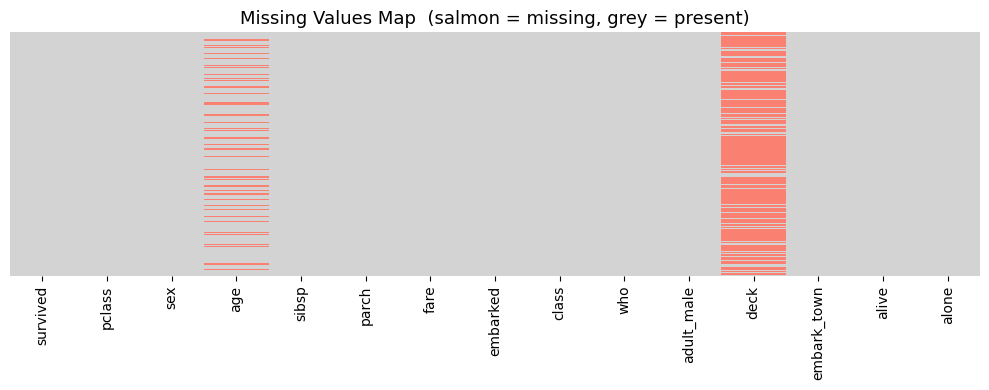

The 'age' and 'cabin' columns have significant missing data — we'll handle these in the preprocessing notebook.


In [5]:
# Visualize missing values as a heatmap
plt.figure(figsize=(10, 4))
mask_missing = df.isnull()
sns.heatmap(mask_missing, cbar=False, yticklabels=False,
            cmap=["lightgrey", "salmon"])
plt.title("Missing Values Map  (salmon = missing, grey = present)", fontsize=13)
plt.tight_layout()
plt.show()
print("The 'age' and 'cabin' columns have significant missing data — we'll handle these in the preprocessing notebook.")

## Step 2 — Distributions

A **distribution** tells you how values are spread across a variable. Understanding distributions helps you:
- Spot outliers (unusual values)
- Decide if data needs transformation
- Understand the typical range of values

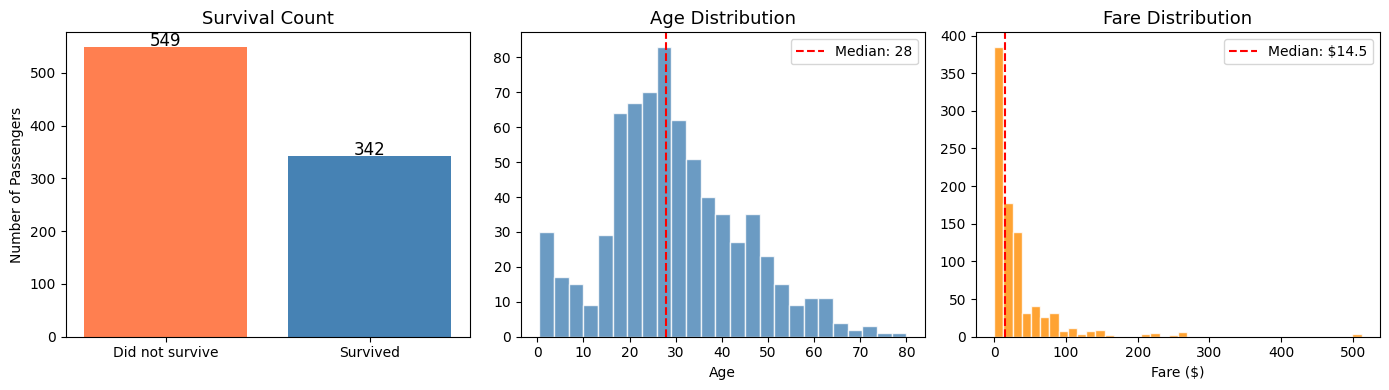

Observations:
  - 549 passengers died, 342 survived
  - Median age: 28 years
  - Fare is heavily right-skewed — a few very expensive tickets pull the average up


In [6]:
# Distribution of survival (our target variable)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Survival
survival_counts = df["survived"].value_counts()
axes[0].bar(["Did not survive", "Survived"], survival_counts.values, color=["coral", "steelblue"])
axes[0].set_title("Survival Count", fontsize=13)
axes[0].set_ylabel("Number of Passengers")
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=12)

# Age distribution
axes[1].hist(df["age"].dropna(), bins=25, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(df["age"].median(), color="red", linestyle="--", label=f"Median: {df['age'].median():.0f}")
axes[1].set_title("Age Distribution", fontsize=13)
axes[1].set_xlabel("Age")
axes[1].legend()

# Fare distribution
axes[2].hist(df["fare"].dropna(), bins=40, color="darkorange", edgecolor="white", alpha=0.8)
axes[2].axvline(df["fare"].median(), color="red", linestyle="--", label=f"Median: ${df['fare'].median():.1f}")
axes[2].set_title("Fare Distribution", fontsize=13)
axes[2].set_xlabel("Fare ($)")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Observations:")
print(f"  - {survival_counts[0]} passengers died, {survival_counts.get(1, survival_counts.iloc[1])} survived")
print(f"  - Median age: {df['age'].median():.0f} years")
print(f"  - Fare is heavily right-skewed — a few very expensive tickets pull the average up")

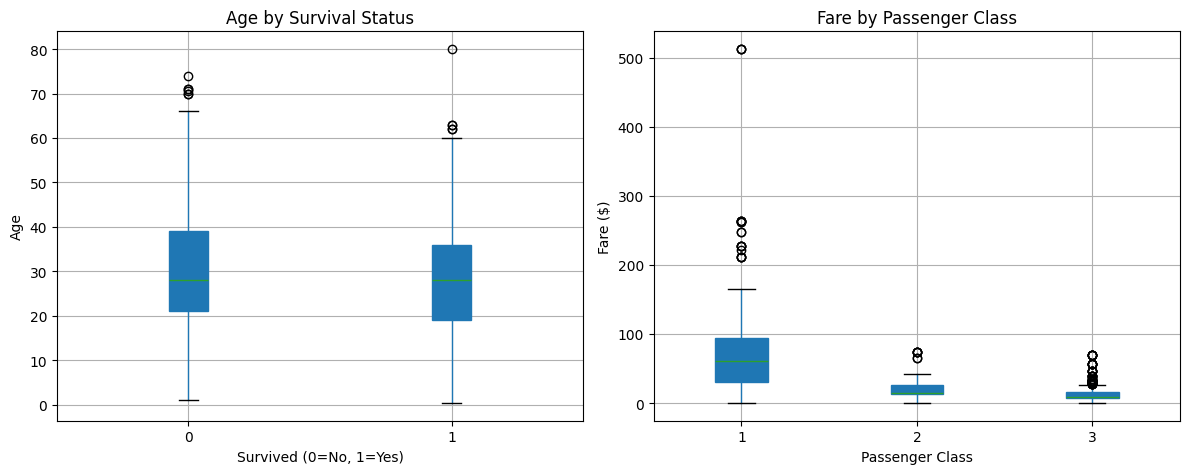

Notice the outliers (dots above/below whiskers) — especially in fare. These are real data points we need to handle carefully.


In [7]:
# Box plots to see spread + outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age by survival
df.boxplot(column="age", by="survived", ax=axes[0], patch_artist=True)
axes[0].set_title("Age by Survival Status", fontsize=13)
axes[0].set_xlabel("Survived (0=No, 1=Yes)")
axes[0].set_ylabel("Age")
plt.sca(axes[0]); plt.title("Age by Survival Status")

# Fare by class
df.boxplot(column="fare", by="pclass", ax=axes[1], patch_artist=True)
axes[1].set_title("Fare by Passenger Class", fontsize=13)
axes[1].set_xlabel("Passenger Class")
axes[1].set_ylabel("Fare ($)")
plt.sca(axes[1]); plt.title("Fare by Passenger Class")

plt.suptitle("")  # remove auto-generated title
plt.tight_layout()
plt.show()

print("Notice the outliers (dots above/below whiskers) — especially in fare. These are real data points we need to handle carefully.")

## Step 3 — Patterns and Correlations

**Correlation** measures whether two variables tend to move together.
- Positive correlation: when one goes up, the other goes up too
- Negative correlation: when one goes up, the other goes down
- No correlation: they're unrelated

For ML, we want features that *correlate with our target* — those will be useful predictors.

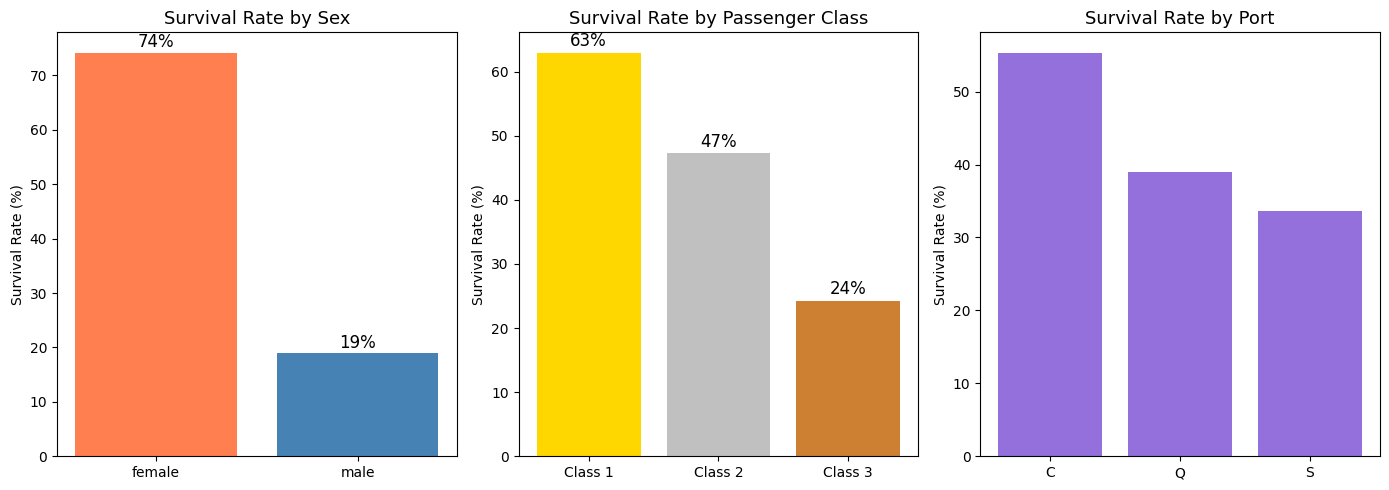

Key finding: Women and first-class passengers had dramatically higher survival rates.
These variables will be very useful features for our prediction model.


In [8]:
# Survival rate by categorical variables
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# By sex
survival_by_sex = df.groupby("sex")["survived"].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values * 100,
            color=["coral", "steelblue"])
axes[0].set_title("Survival Rate by Sex", fontsize=13)
axes[0].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v * 100 + 1, f"{v:.0%}", ha="center", fontsize=12)

# By passenger class
survival_by_class = df.groupby("pclass")["survived"].mean()
axes[1].bar([f"Class {c}" for c in survival_by_class.index], survival_by_class.values * 100,
            color=["gold", "silver", "#CD7F32"])
axes[1].set_title("Survival Rate by Passenger Class", fontsize=13)
axes[1].set_ylabel("Survival Rate (%)")
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v * 100 + 1, f"{v:.0%}", ha="center", fontsize=12)

# By embarkation port
survival_by_port = df.groupby("embarked")["survived"].mean()
axes[2].bar(survival_by_port.index, survival_by_port.values * 100, color="mediumpurple")
axes[2].set_title("Survival Rate by Port", fontsize=13)
axes[2].set_ylabel("Survival Rate (%)")

plt.tight_layout()
plt.show()

print("Key finding: Women and first-class passengers had dramatically higher survival rates.")
print("These variables will be very useful features for our prediction model.")

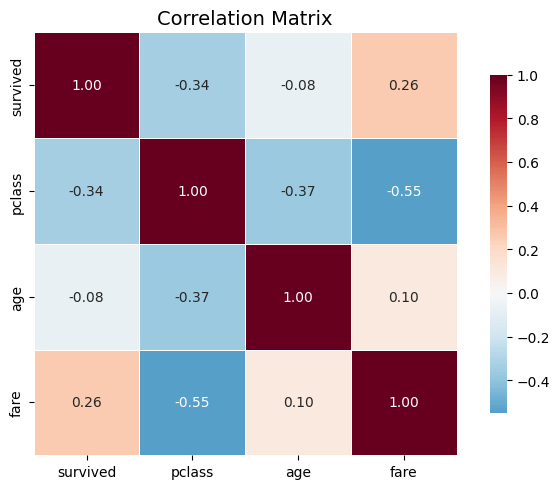

Reading the heatmap:
  - pclass and survived: -0.34 (negative — higher class number = lower survival)
  - fare and survived:    0.26 (positive — higher fare = more likely to survive)
  - These aren't huge correlations, but they're meaningful signal for ML


In [9]:
# Correlation heatmap for numeric features
numeric_cols = ["survived", "pclass", "age", "fare"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("Reading the heatmap:")
print("  - pclass and survived: -0.34 (negative — higher class number = lower survival)")
print("  - fare and survived:    0.26 (positive — higher fare = more likely to survive)")
print("  - These aren't huge correlations, but they're meaningful signal for ML")

## Step 4 — EDA Summary and Feature Notes

Good EDA always ends with a written summary. This becomes your reference when you move to preprocessing.

In [10]:
print("=" * 60)
print("EDA SUMMARY — Titanic Dataset")
print("=" * 60)
print(f"\nDataset size: {df.shape[0]} passengers × {df.shape[1]} features")
print(f"Target: 'survived' (0 = died, 1 = survived)")
print(f"Survival rate: {df['survived'].mean():.1%}")

print("\n--- Missing Values ---")
for col in df.columns:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        print(f"  {col}: {n_miss} missing ({n_miss/len(df):.0%})")

print("\n--- Useful Features (high correlation with survival) ---")
print("  sex      → very strong predictor (women survived more)")
print("  pclass   → strong predictor (1st class survived more)")
print("  age      → moderate (children prioritized)")
print("  fare     → moderate (proxy for wealth/class)")

print("\n--- Next Steps (Preprocessing) ---")
print("  1. Fill missing 'age' values (median imputation)")
print("  2. Drop 'cabin' — too many missing values (77%)")
print("  3. Encode 'sex' and 'embarked' as numbers (ML needs numbers)")
print("  4. Scale 'age' and 'fare' (they're on very different scales)")

EDA SUMMARY — Titanic Dataset

Dataset size: 891 passengers × 15 features
Target: 'survived' (0 = died, 1 = survived)
Survival rate: 38.4%

--- Missing Values ---
  age: 177 missing (20%)
  embarked: 2 missing (0%)
  deck: 688 missing (77%)
  embark_town: 2 missing (0%)

--- Useful Features (high correlation with survival) ---
  sex      → very strong predictor (women survived more)
  pclass   → strong predictor (1st class survived more)
  age      → moderate (children prioritized)
  fare     → moderate (proxy for wealth/class)

--- Next Steps (Preprocessing) ---
  1. Fill missing 'age' values (median imputation)
  2. Drop 'cabin' — too many missing values (77%)
  3. Encode 'sex' and 'embarked' as numbers (ML needs numbers)
  4. Scale 'age' and 'fare' (they're on very different scales)


---

## ✋ Exercise — Explore a New Dataset

Now practice EDA on your own. Use the **Tips** dataset (restaurant tipping data).

In [11]:
# Load the Tips dataset
try:
    tips = sns.load_dataset("tips")
except:
    # Minimal fallback
    np.random.seed(42)
    tips = pd.DataFrame({
        "total_bill": np.random.lognormal(2.8, 0.5, 244).round(2),
        "tip": np.random.lognormal(1.5, 0.4, 244).round(2),
        "sex": np.random.choice(["Male", "Female"], 244),
        "smoker": np.random.choice(["Yes", "No"], 244),
        "day": np.random.choice(["Sun", "Sat", "Thur", "Fri"], 244),
        "size": np.random.randint(1, 7, 244),
    })

print("Tips dataset:", tips.shape)
print(tips.head())

Tips dataset: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [12]:
# TASK 1: Check for missing values in the tips dataset
# YOUR CODE HERE:

# TASK 2: Plot a histogram of 'total_bill'
# YOUR CODE HERE:

# TASK 3: Find the average tip percentage by day
# Hint: tip_pct = tip / total_bill * 100
# Then group by 'day' and take the mean
# YOUR CODE HERE:

print("Complete the three tasks above!")

Complete the three tasks above!
